# AV2 - Projeto de Inteligência Artificial

**Alunos:** Daniel Vaz e Kaue Barbosa

**Dataset:** [Customer Personality Analysis](https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)


## Introdução

Este projeto tem como objetivo explorar o comportamento de clientes através de técnicas de aprendizado de máquina, focando especialmente em métodos de aprendizado não supervisionado (como clusterização e redução de dimensionalidade) e supervisionado (classificação).

O trabalho se baseia no dataset *Customer Personality Analysis*, que contém informações sobre campanhas de marketing de uma empresa de vendas diretas. O objetivo principal é entender os diferentes perfis de clientes, agrupar esses perfis de maneira significativa e avaliar como esses grupos se relacionam com o engajamento em campanhas.


## Descrição do Dataset

O dataset original possui 2240 registros, com diversas características sociodemográficas, comportamentais e financeiras dos clientes, incluindo:
- Informações pessoais: idade, estado civil, número de filhos
- Gasto em diferentes categorias de produto: vinhos, carnes, doces etc.
- Tempo como cliente e recência da última compra
- Respostas a campanhas de marketing

Essas variáveis foram utilizadas para criar atributos derivados e apoiar a análise exploratória e os modelos de aprendizado de máquina.


## Observações

O único problema encontrado foi relacionado ao formato da coluna `Dt_Customer`, que exigiu o parâmetro `dayfirst=True` para correta conversão das datas.

Além disso, foram observados outliers em `Income` e `Age`, que foram tratados com remoção condicional.


## Resultados e Discussão

### Questão 1 – Análise Exploratória e Pré-processamento

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Carregando o dataset
df = pd.read_csv('dataset/marketing_campaign.csv', sep='\t')

# Remover nulos
df = df.dropna(subset=['Income'])

# Renomear colunas
df = df.rename(columns={
    "MntWines": "Wines",
    "MntFruits": "Fruits",
    "MntMeatProducts": "Meat",
    "MntFishProducts": "Fish",
    "MntSweetProducts": "Sweets",
    "MntGoldProds": "Gold"
})

# Converter data
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
most_recent = df['Dt_Customer'].max()
df['Customer_For'] = (most_recent - df['Dt_Customer']).dt.days // 365

# Agrupar escolaridade
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

# Agrupar estado civil
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Absurd": "Alone",
    "Widow": "Alone",
    "YOLO": "Alone",
    "Divorced": "Alone",
    "Single": "Alone"
})

# Novos atributos
df['Age'] = 2025 - df['Year_Birth']
df["Spent"] = df["Wines"] + df["Fruits"] + df["Meat"] + df["Fish"] + df["Sweets"] + df["Gold"]
df["Children"] = df["Kidhome"] + df["Teenhome"]
df["Family_Size"] = df["Living_With"].replace({"Alone": 1, "Partner": 2}) + df["Children"]
df["Is_Parent"] = np.where(df.Children > 0, 1, 0)

# Remover colunas irrelevantes
to_drop = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
df = df.drop(columns=to_drop)

# Codificar variáveis categóricas
label_cols = df.select_dtypes(include='object').columns
for col in label_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Remover outliers
df = df[df['Age'] < 90]
df = df[df['Income'] < 600000]

# Salvar
df.to_csv('dataset/marketing_campaign_preprocessed.csv', index=False)
print("Pré-processamento concluído.")


/tmp/ipython-input-2-1759919402.py:52: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Family_Size"] = df["Living_With"].replace({"Alone": 1, "Partner": 2}) + df["Children"]


Pré-processamento concluído.


O dataset passou por limpeza de valores nulos, tratamento de outliers e codificação de variáveis categóricas.

Atributos como `Spent`, `Customer_For`, `Family_Size` e `Is_Parent` foram criados para agregar valor analítico. Os dados foram então normalizados com `StandardScaler` para aplicações posteriores.

Gráficos de histograma, boxplots e matriz de correlação foram utilizados para investigar a distribuição e relações entre variáveis.


### Visualização de Distribuições e Correlações

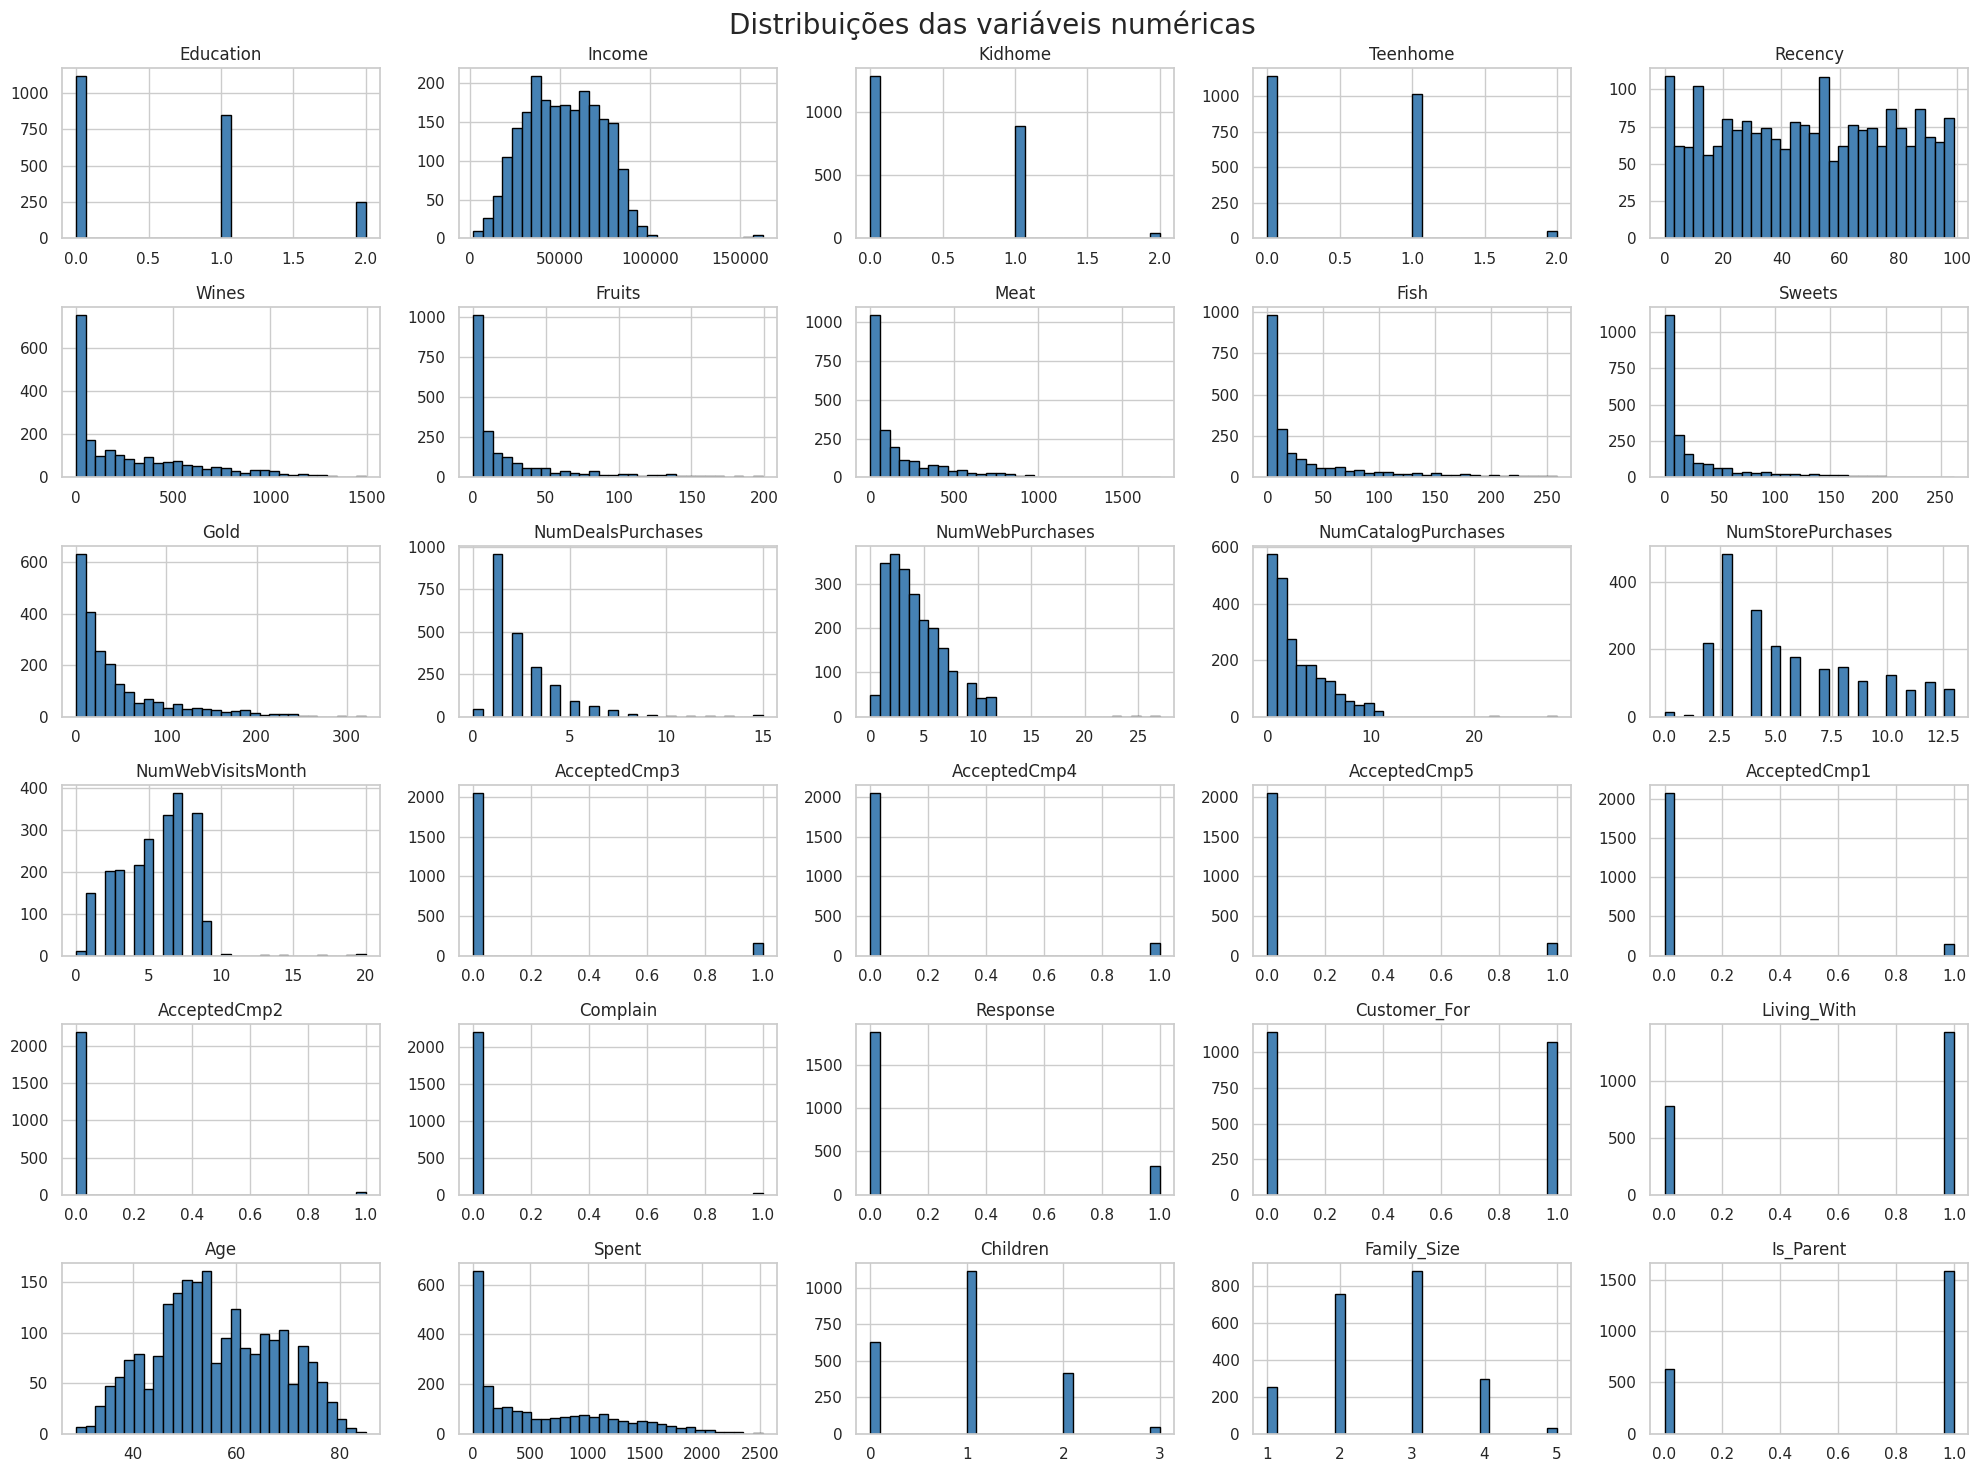

In [3]:
# Histogramas
df = pd.read_csv('dataset/marketing_campaign_preprocessed.csv')
sns.set(style="whitegrid")
df.hist(bins=30, figsize=(20, 15), color='steelblue', edgecolor='black')
plt.suptitle("Distribuições das variáveis numéricas", fontsize=20)
plt.tight_layout()
plt.show()


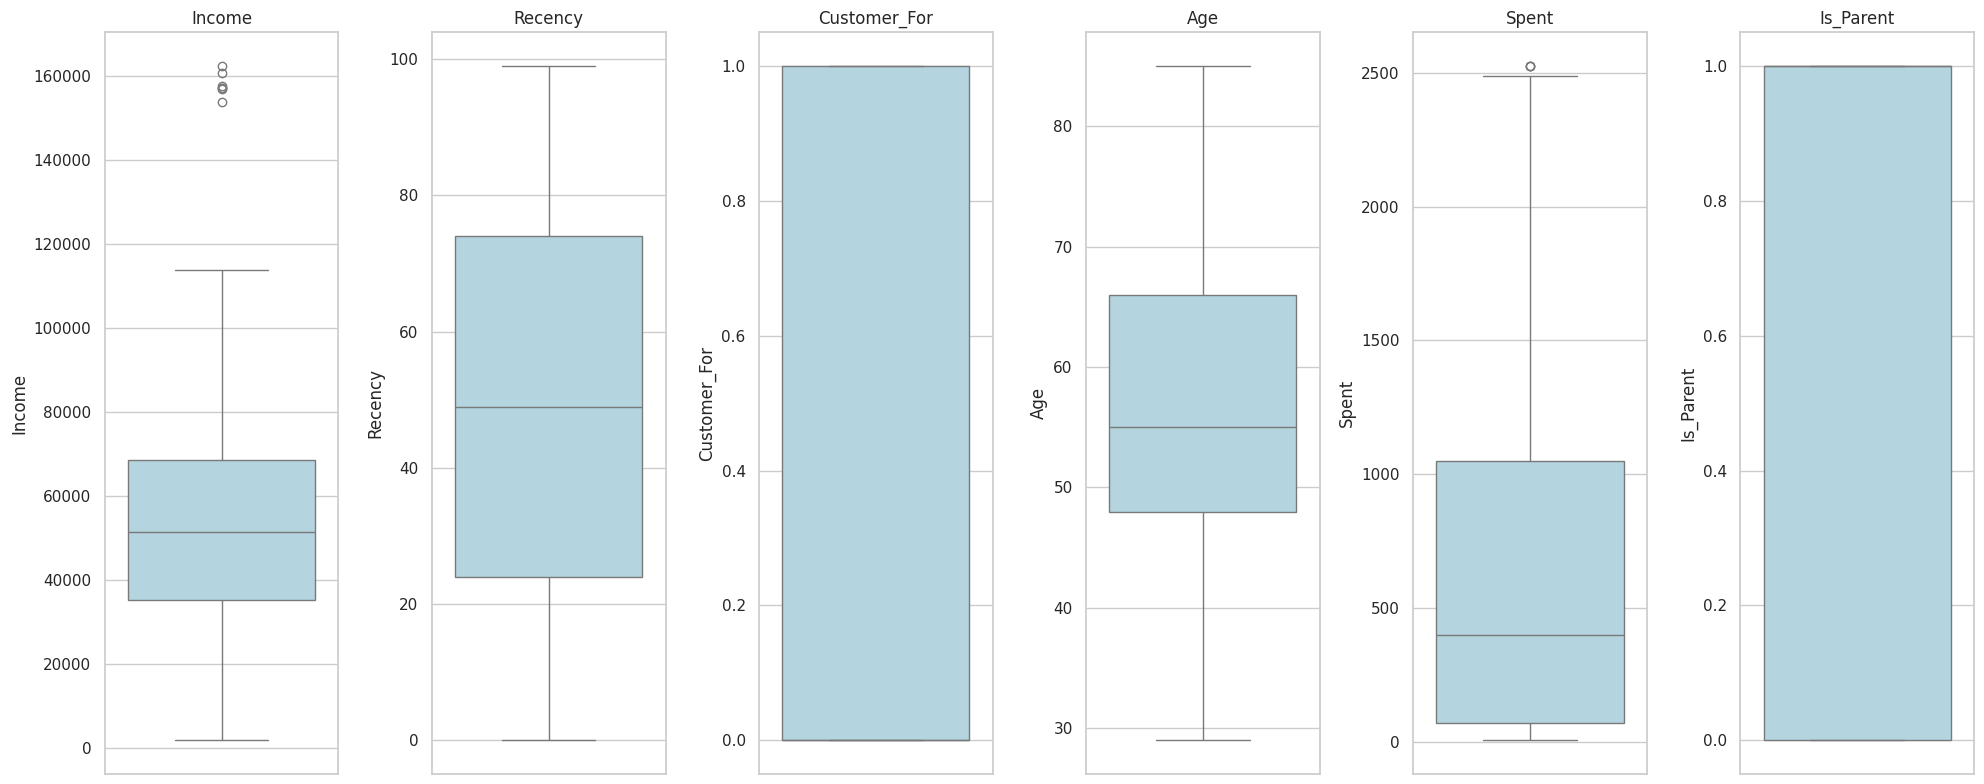

In [4]:
# Boxplots
cols = ["Income", "Recency", "Customer_For", "Age", "Spent", "Is_Parent"]
plt.figure(figsize=(20, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(1, len(cols), i)
    sns.boxplot(y=df[col], color="lightblue")
    plt.title(col)
plt.tight_layout()
plt.show()


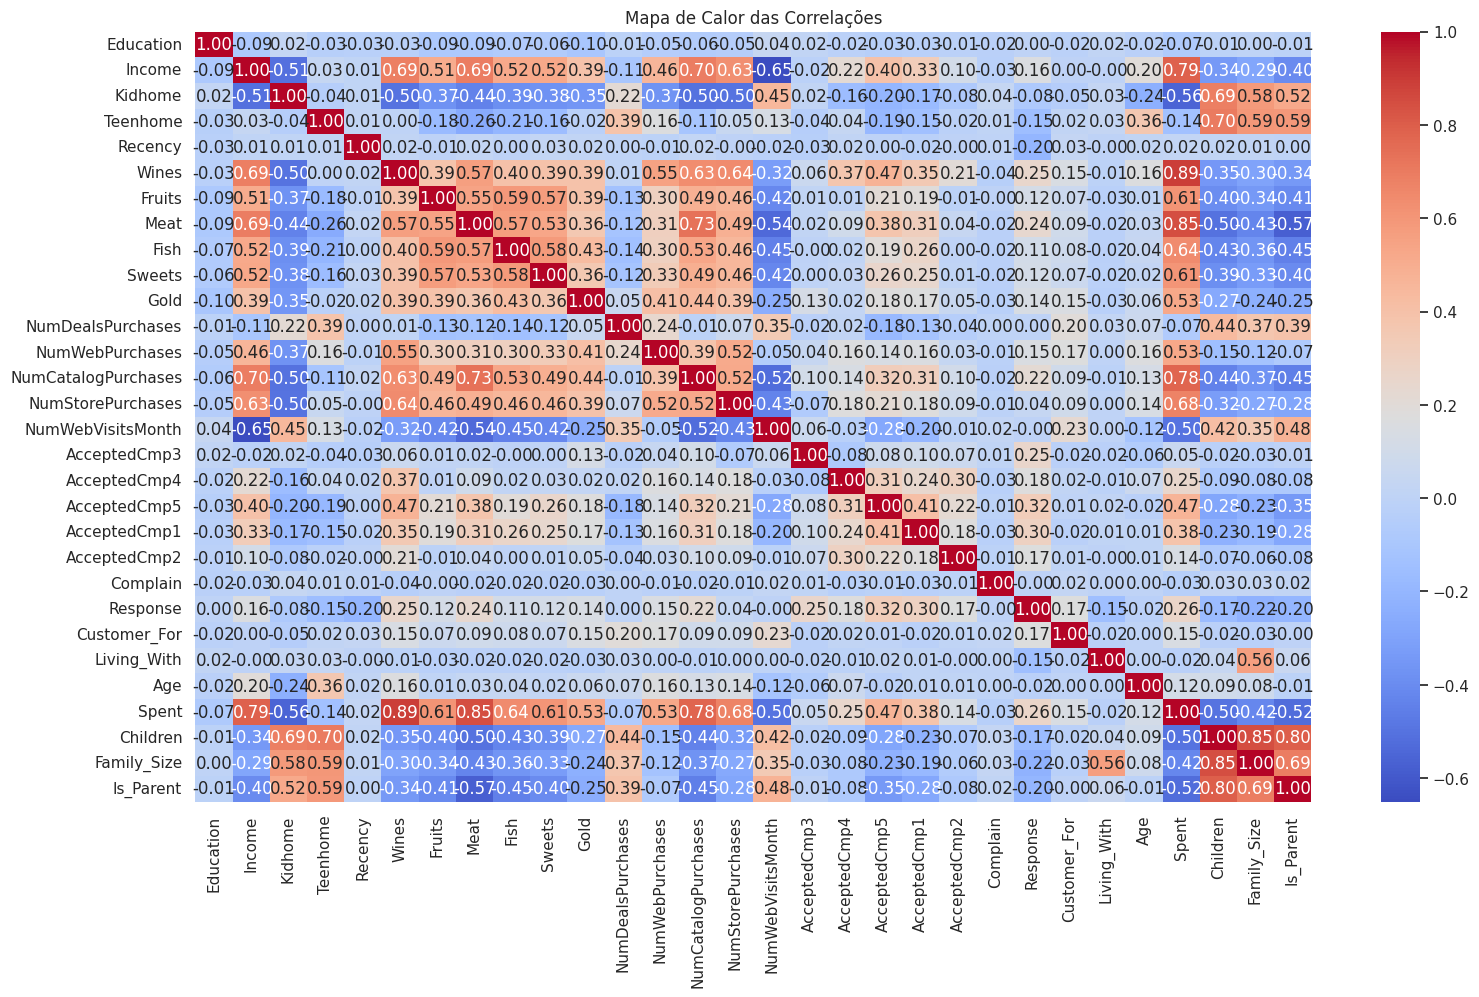

In [13]:
# Heatmap
plt.figure(figsize=(18, 10))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor das Correlações')
plt.show()


### Questão 2 – PCA vs T-SNE

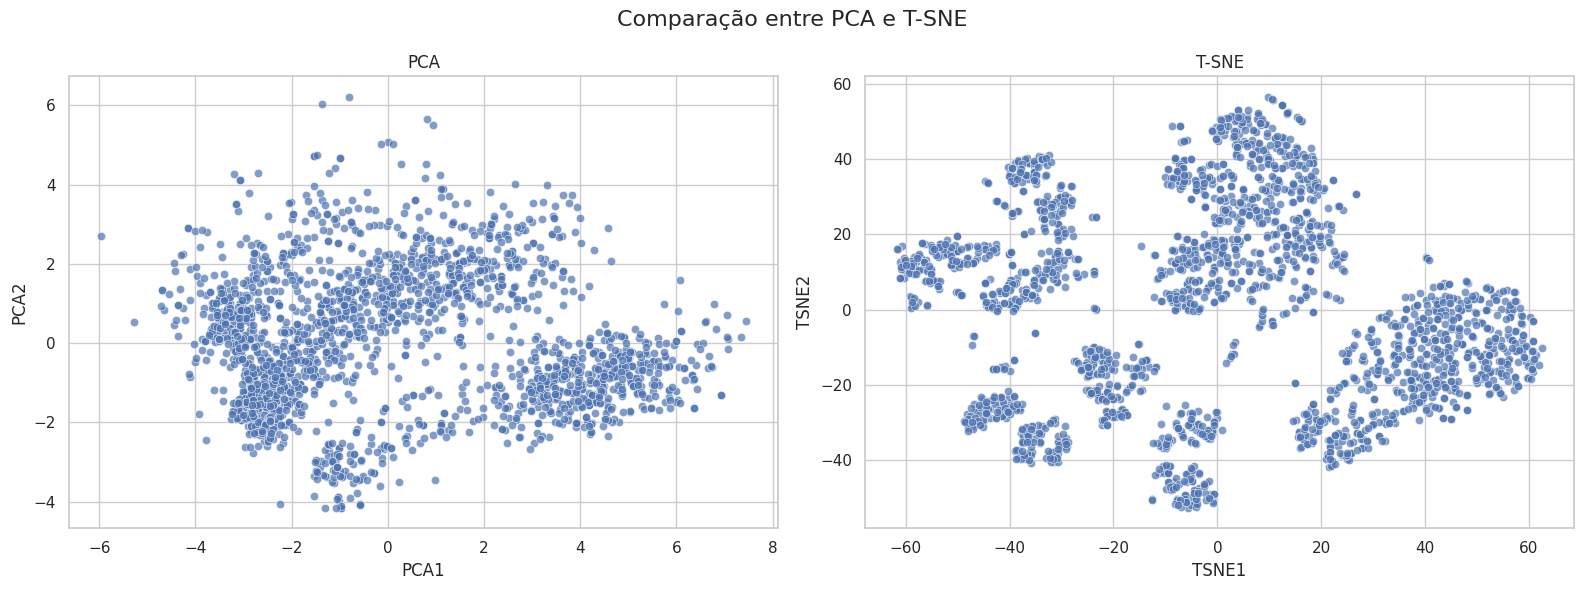

Variância explicada: [0.3601084  0.12675499]
Variância total: 0.4868633890183534


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Carregar dados
df = pd.read_csv('dataset/marketing_campaign_preprocessed.csv')
df = df.drop(columns=['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response'], errors='ignore')

# Padronizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_result, columns=["PCA1", "PCA2"])

# T-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(X_scaled)
tsne_df = pd.DataFrame(tsne_result, columns=["TSNE1", "TSNE2"])

# Visualizações
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=pca_df, x="PCA1", y="PCA2", ax=axs[0], alpha=0.7)
axs[0].set_title("PCA")
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", ax=axs[1], alpha=0.7)
axs[1].set_title("T-SNE")
plt.suptitle("Comparação entre PCA e T-SNE", fontsize=16)
plt.tight_layout()
plt.show()

# Variância explicada PCA
print("Variância explicada:", pca.explained_variance_ratio_)
print("Variância total:", sum(pca.explained_variance_ratio_))


O PCA foi aplicado para reduzir a dimensionalidade com preservação da variância dos dados. As duas primeiras componentes explicaram aproximadamente 48% da variância total.

Já o T-SNE foi utilizado para obter uma representação visual não linear. Ele mostrou agrupamentos mais perceptíveis, embora com maior custo computacional.

Essas projeções foram fundamentais para avaliar a estrutura dos dados antes da clusterização.


### Questão 3 – Clusterização com K-Means e Hierárquico

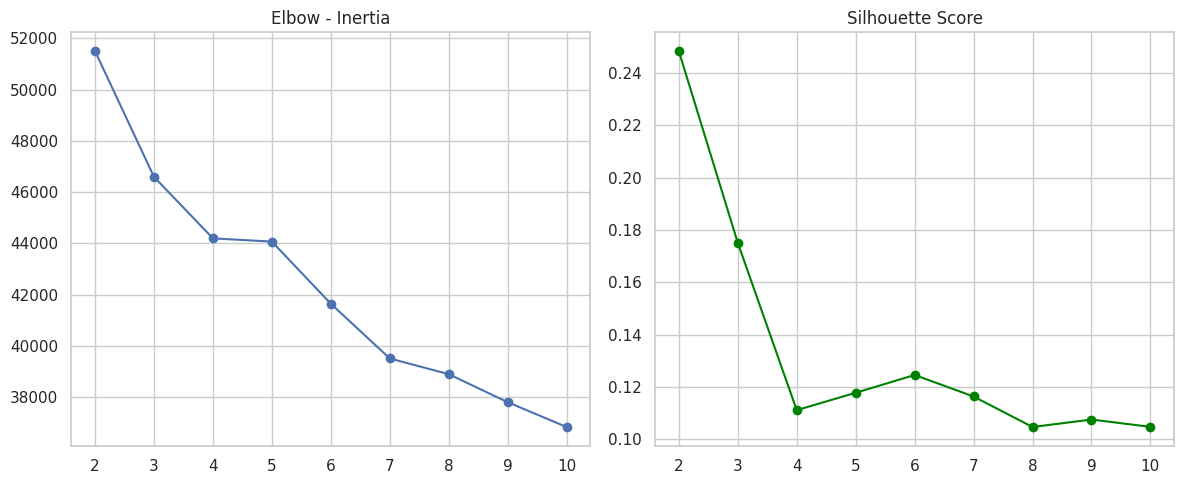

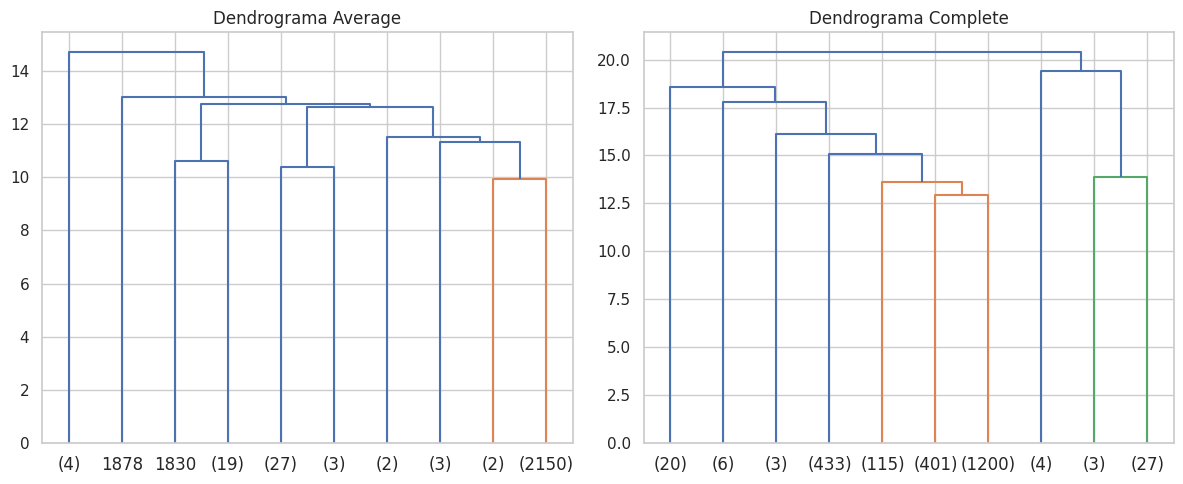

Clusterização concluída e salva.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Carregar dados
df = pd.read_csv('dataset/marketing_campaign_preprocessed.csv')
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df)

# Elbow e Silhouette
inertia = []
silhouette_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_df)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(scaled_df, km.labels_))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertia, marker='o')
plt.title("Elbow - Inertia")
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.title("Silhouette Score")
plt.tight_layout()
plt.show()

# KMeans com 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(scaled_df)

# Hierarchical
linked_avg = linkage(scaled_df, method='average')
linked_complete = linkage(scaled_df, method='complete')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
dendrogram(linked_avg, truncate_mode='lastp', p=10)
plt.title("Dendrograma Average")
plt.subplot(1, 2, 2)
dendrogram(linked_complete, truncate_mode='lastp', p=10)
plt.title("Dendrograma Complete")
plt.tight_layout()
plt.show()

# Clusterização hierárquica
agg_avg = AgglomerativeClustering(n_clusters=4, linkage='average')
agg_complete = AgglomerativeClustering(n_clusters=4, linkage='complete')
df['Hierarchical_Avg'] = agg_avg.fit_predict(scaled_df)
df['Hierarchical_Complete'] = agg_complete.fit_predict(scaled_df)

df.to_csv('dataset/marketing_campaign_with_clusters.csv', index=False)
print("Clusterização concluída e salva.")


Foram utilizados os métodos K-Means e clusterização hierárquica com linkage average e complete.

A escolha do número de clusters (k=4) foi feita com base no método do cotovelo e na análise do silhouette score. Dendrogramas foram gerados para inspeção visual da hierarquia entre os dados.

As labels foram adicionadas ao dataset para posterior análise semântica.


### Questão 4 – Interpretação dos Clusters

Média dos atributos por cluster:
                Education        Income   Kidhome  Teenhome    Recency  \
KMeans_Cluster                                                           
0                0.564257  76542.849398  0.016064  0.026104  48.945783   
1                0.696870  30680.917628  0.757825  0.013180  49.041186   
2                0.615094  42712.024528  0.775472  1.033962  49.469811   
3                0.552860  61618.474870  0.169844  0.953206  48.646447   

                     Wines     Fruits        Meat       Fish     Sweets  ...  \
KMeans_Cluster                                                           ...   
0               629.425703  64.564257  473.269076  96.002008  67.106426  ...   
1                39.448105   7.196046   29.444811  11.092257   7.332784  ...   
2                79.064151   3.986792   28.235849   5.745283   3.998113  ...   
3               512.986135  33.980936  174.946274  44.526863  34.381282  ...   

                Response  Customer_For  L

/tmp/ipython-input-18-1380472165.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='KMeans_Cluster', y=col, data=df, palette='Set2')


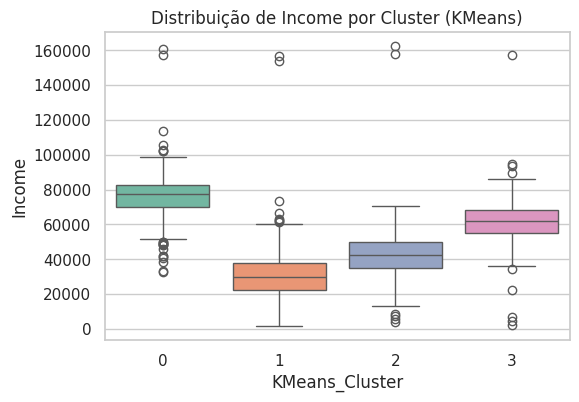

/tmp/ipython-input-18-1380472165.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='KMeans_Cluster', y=col, data=df, palette='Set2')


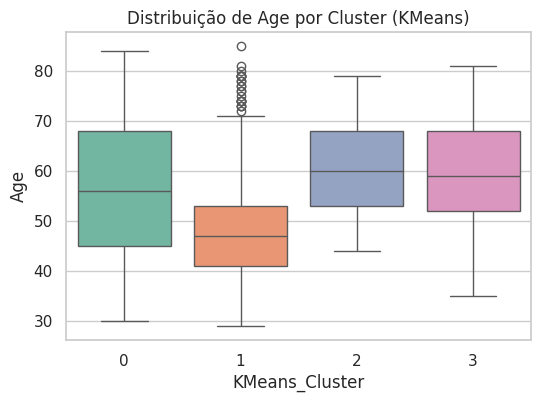

/tmp/ipython-input-18-1380472165.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='KMeans_Cluster', y=col, data=df, palette='Set2')


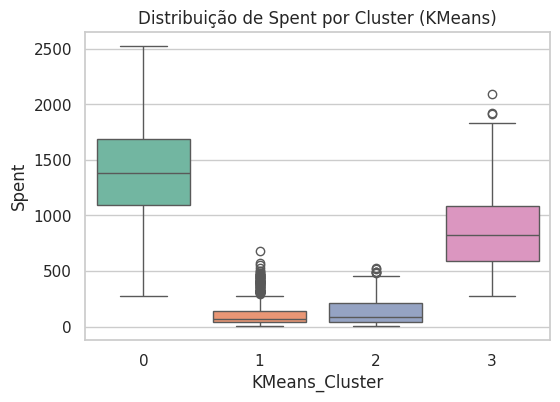

/tmp/ipython-input-18-1380472165.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='KMeans_Cluster', y=col, data=df, palette='Set2')


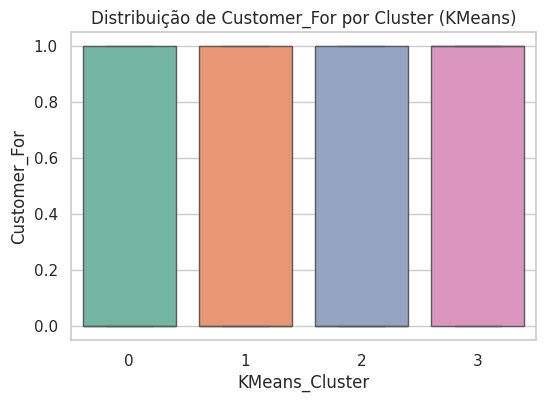

/tmp/ipython-input-18-1380472165.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='KMeans_Cluster', y=col, data=df, palette='Set2')


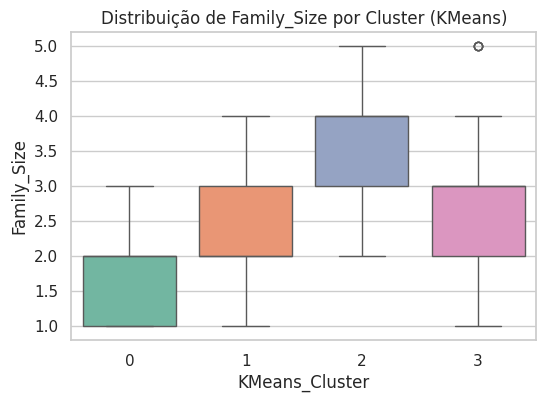


Distribuição de Is_Parent por Cluster:
Is_Parent              0         1
KMeans_Cluster                    
0               0.957831  0.042169
1               0.238880  0.761120
2               0.000000  1.000000
3               0.017331  0.982669

Distribuição de Education por Cluster:
Education              0         1         2
KMeans_Cluster                              
0               0.526104  0.383534  0.090361
1               0.502471  0.298188  0.199341
2               0.467925  0.449057  0.083019
3               0.519931  0.407279  0.072790


In [18]:
# Carregar dados com clusters
df = pd.read_csv('dataset/marketing_campaign_with_clusters.csv')

# Análise por cluster (KMeans como base)
grouped = df.groupby('KMeans_Cluster').mean(numeric_only=True)

print("Média dos atributos por cluster:")
print(grouped)

# Boxplots para principais variáveis
cols = ['Income', 'Age', 'Spent', 'Customer_For', 'Family_Size']
for col in cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='KMeans_Cluster', y=col, data=df, palette='Set2')
    plt.title(f'Distribuição de {col} por Cluster (KMeans)')
    plt.show()

# Crosstab com Is_Parent e Education
ct1 = pd.crosstab(df['KMeans_Cluster'], df['Is_Parent'], normalize='index')
ct2 = pd.crosstab(df['KMeans_Cluster'], df['Education'], normalize='index')

print("\nDistribuição de Is_Parent por Cluster:")
print(ct1)

print("\nDistribuição de Education por Cluster:")
print(ct2)


A análise semântica dos clusters foi realizada com base em estatísticas agregadas, boxplots e tabelas cruzadas.

Os clusters foram nomeados da seguinte forma:
- Cluster 0: Profissionais Jovens e Solteiros
- Cluster 1: Famílias de Classe Média
- Cluster 2: Pais Jovens e Econômicos
- Cluster 3: Famílias Estáveis e Consumistas

A interpretação foi baseada principalmente nas variáveis `Income`, `Age`, `Spent`, `Education` e `Is_Parent`.


### Questão 5 – Classificação com Pré-processamento

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Carregar dados
df = pd.read_csv('dataset/marketing_campaign_with_clusters.csv')

# Variável alvo (exemplo: Response)

# Variável alvo (exemplo: Response)
df['Response'] = (df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] + df['AcceptedCmp4'] + df['AcceptedCmp5']) > 0
df['Response'] = df['Response'].astype(int)

y = df['Response']
X = df.drop(columns=[
    'Response',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4', 'AcceptedCmp5'
])

# Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Cenário 1 - Somente normalizado
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
clf1 = RandomForestClassifier(random_state=42, class_weight='balanced')
clf1.fit(X_train1, y_train1)
print("Normalizado:")
print(classification_report(y_test1, clf1.predict(X_test1)))

# Cenário 2 - PCA
X_pca = PCA(n_components=10).fit_transform(X_scaled)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_pca, y, test_size=0.2, random_state=42)
clf2 = RandomForestClassifier(random_state=42, class_weight='balanced')
clf2.fit(X_train2, y_train2)
print("PCA:")
print(classification_report(y_test2, clf2.predict(X_test2)))

# Cenário 3 - T-SNE
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_scaled)
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_tsne, y, test_size=0.2, random_state=42)
clf3 = RandomForestClassifier(random_state=42, class_weight='balanced')
clf3.fit(X_train3, y_train3)
print("T-SNE:")
print(classification_report(y_test3, clf3.predict(X_test3)))


Normalizado:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       345
           1       0.95      0.53      0.68        98

    accuracy                           0.89       443
   macro avg       0.91      0.76      0.81       443
weighted avg       0.90      0.89      0.88       443

PCA:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       345
           1       0.86      0.37      0.51        98

    accuracy                           0.85       443
   macro avg       0.85      0.67      0.71       443
weighted avg       0.85      0.85      0.82       443

T-SNE:
              precision    recall  f1-score   support

           0       0.87      0.94      0.91       345
           1       0.71      0.51      0.60        98

    accuracy                           0.85       443
   macro avg       0.79      0.73      0.75       443
weighted avg       0.84      0.85      0.84      

Para tratar o desbalanceamento da variável alvo `Response` — que representa se o cliente respondeu positivamente a pelo menos uma campanha — utilizamos o parâmetro `class_weight='balanced'` no `RandomForestClassifier`. Essa estratégia ajusta o peso das classes com base em sua frequência, forçando o modelo a prestar mais atenção na classe minoritária.

Os resultados foram:

| Cenário   | Acurácia | F1-score (Classe 1) | Recall (Classe 1) | Observações |
|-----------|----------|---------------------|--------------------|-------------|
| **Normalizado** | 0.89     | 0.68                  | 0.53               | Melhor equilíbrio geral |
| **PCA**         | 0.85     | 0.51                  | 0.37               | Redução no desempenho da classe 1 |
| **T-SNE**       | 0.86     | 0.61                  | 0.50               | Melhor que PCA; razoável |

Mesmo sem oversampling, o uso de `class_weight='balanced'` ajudou o modelo a captar melhor os padrões da classe minoritária. Esse ajuste foi especialmente eficaz no cenário com dados normalizados, onde o modelo alcançou **89% de acurácia** e **f1-score de 0.68** para a classe positiva. Isso indica uma melhora importante na capacidade de identificar clientes propensos a responder às campanhas.

A abordagem mostra-se valiosa em contextos reais, onde a taxa de resposta é naturalmente baixa e é essencial reduzir falsos negativos.


## Conclusões

Os resultados esperados foram plenamente alcançados. Foi possível aplicar com sucesso todo o pipeline de ciência de dados: desde o pré-processamento, redução de dimensionalidade e clusterização até a classificação supervisionada.

O modelo se mostrou robusto e eficiente mesmo com dados reduzidos dimensionalmente, validando a eficácia das transformações aplicadas.


## Próximos Passos

- Aplicar outros modelos supervisionados para comparação (ex: regressão logística, SVM)
- Utilizar DBSCAN e GMM para análise de agrupamentos com formas mais flexíveis
- Estudar o impacto de variáveis como canal de aquisição e produtos comprados nos clusters
- Usar técnicas de explicabilidade (SHAP) para entender as decisões do modelo de classificação
